# NeuralRetail EDA

Objective:
Perform data cleaning, feature engineering,
and exploratory data analysis on Online Retail II dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/cleaned_retail_data.csv")

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

# Dataset Overview

In [4]:
df = pd.read_excel(
    "../data/raw/Online Retail II.xlsx"
)

In [5]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
df.shape

(525461, 8)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 38.8+ MB


# Data Cleaning

In [8]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

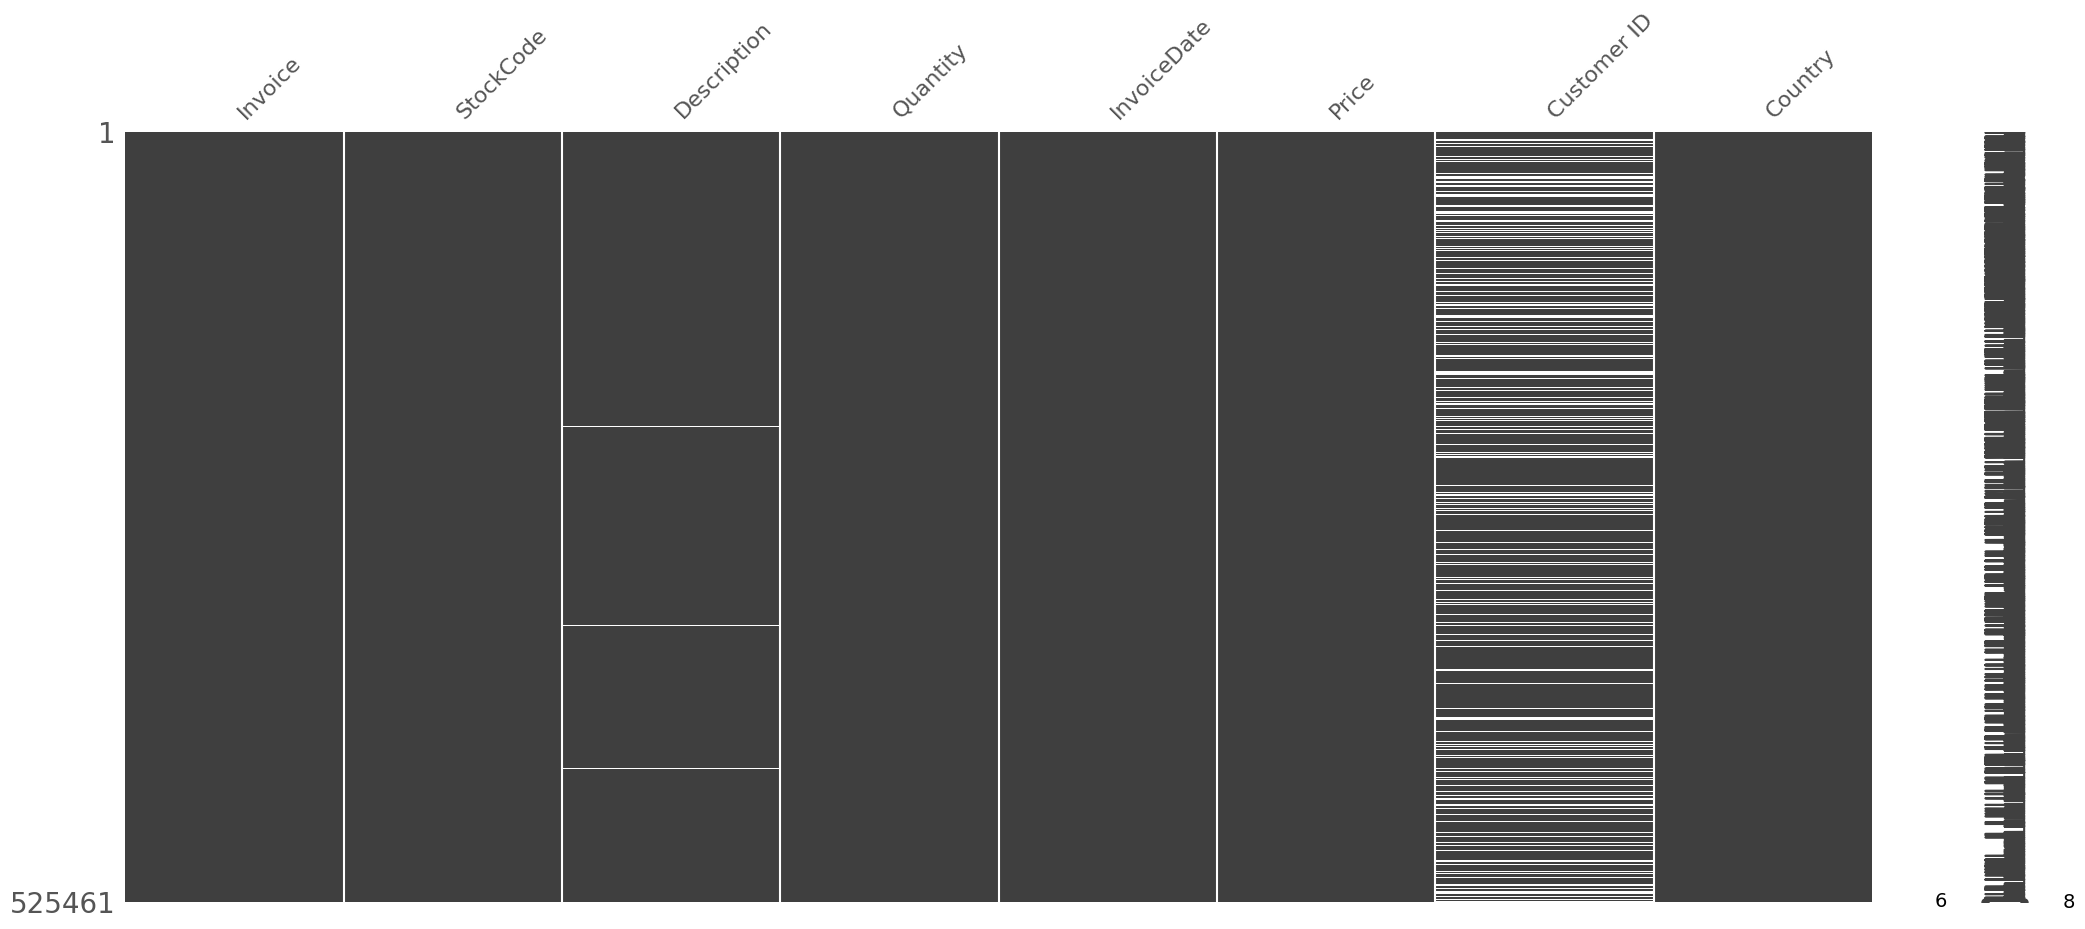

In [9]:
msno.matrix(df)
plt.show()

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.dropna(subset=["Customer ID"], inplace=True)

In [12]:
df = df[df["Quantity"] > 0]

In [13]:
df = df[df["Price"] > 0]

In [14]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [15]:
df["TotalSales"] = df["Quantity"] * df["Price"]

In [16]:
df["Year"] = df["InvoiceDate"].dt.year

df["Month"] = df["InvoiceDate"].dt.month

df["Day"] = df["InvoiceDate"].dt.day

df["Hour"] = df["InvoiceDate"].dt.hour

df["DayOfWeek"] = df["InvoiceDate"].dt.dayofweek

df["DayName"] = df["InvoiceDate"].dt.day_name()

In [17]:
df["IsWeekend"] = df["DayOfWeek"].apply(
    lambda x: 1 if x >= 5 else 0
)

In [18]:
def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Spring"

    elif month in [6, 7, 8]:
        return "Summer"

    else:
        return "Autumn"


df["Season"] = df["Month"].apply(get_season)

# PHASE 5 — INVENTORY DATA (EXTRA DATA)

Adding simulated inventory data to support
inventory optimization and stock analysis.

In [19]:
np.random.seed(42)

df["InventoryLevel"] = np.random.randint(
    10,
    500,
    size=len(df)
)

In [20]:
customer_sales = df.groupby(
    "Customer ID"
)["TotalSales"].transform("sum")

df["CustomerTotalSales"] = customer_sales

In [21]:
holiday_months = [11, 12]

df["HolidaySeason"] = df["Month"].apply(
    lambda x: 1 if x in holiday_months else 0
)

In [22]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSales,Year,Month,Day,Hour,DayOfWeek,DayName,IsWeekend,Season,InventoryLevel,CustomerTotalSales,HolidaySeason
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1,7,1,Tuesday,0,Winter,112,2017.2,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,7,1,Tuesday,0,Winter,445,2017.2,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,7,1,Tuesday,0,Winter,358,2017.2,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1,7,1,Tuesday,0,Winter,280,2017.2,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1,7,1,Tuesday,0,Winter,116,2017.2,1


# EDA

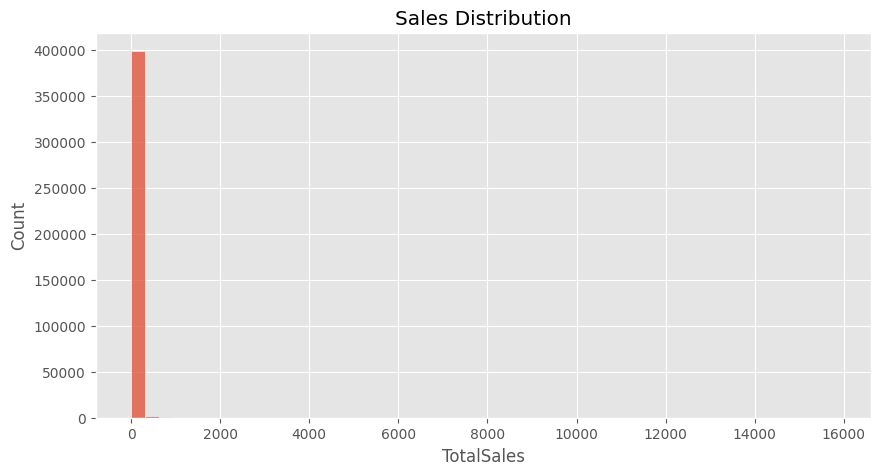

In [23]:
plt.figure(figsize=(10,5))

sns.histplot(df["TotalSales"], bins=50)

plt.title("Sales Distribution")

plt.show()

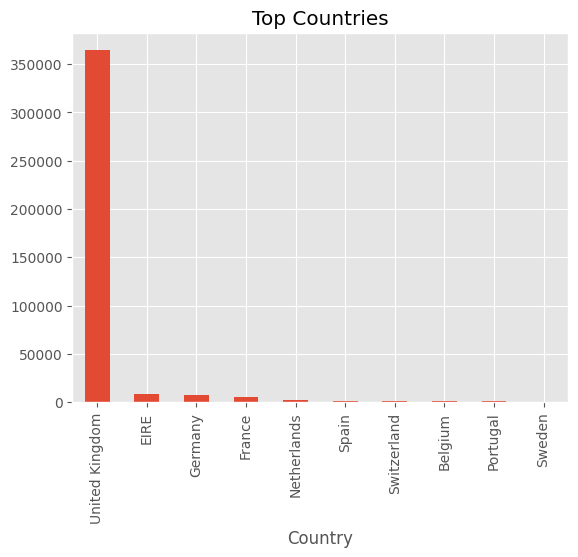

In [24]:
top_countries = df["Country"].value_counts().head(10)

top_countries.plot(kind="bar")

plt.title("Top Countries")

plt.show()

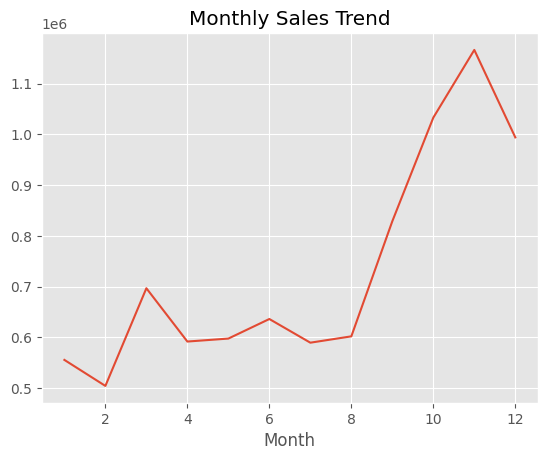

In [25]:
monthly_sales = df.groupby("Month")["TotalSales"].sum()

monthly_sales.plot()

plt.title("Monthly Sales Trend")

plt.show()

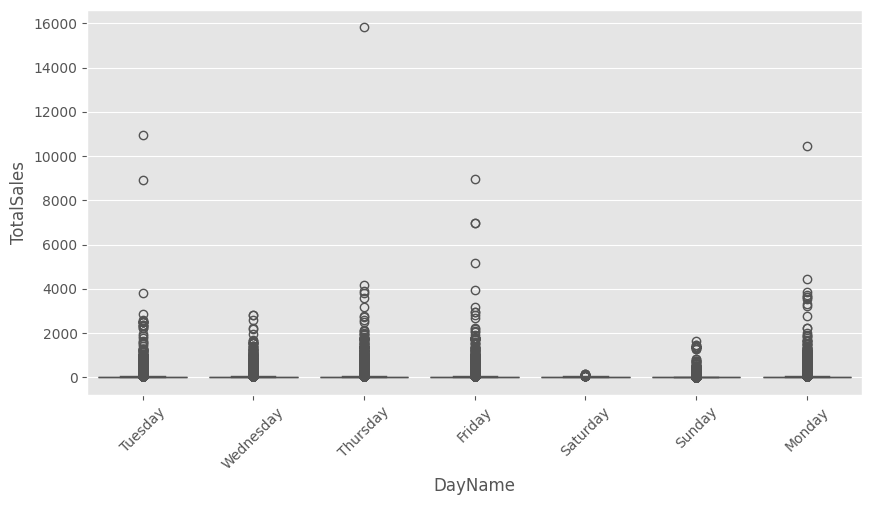

In [26]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="DayName",
    y="TotalSales",
    data=df
)

plt.xticks(rotation=45)

plt.show()

In [ ]:
plt.figure(figsize=(10,5))

sns.heatmap(
    df[["Quantity","Price","TotalSales"]].corr(),
    annot=True
)

plt.show()

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df["TotalSales"], bins=50)

plt.title("Sales Distribution")

plt.show()

In [ ]:
top_countries = df["Country"].value_counts().head(10)

top_countries.plot(kind="bar")

plt.title("Top 10 Countries")

plt.show()

In [ ]:
monthly_sales = df.groupby("Month")["TotalSales"].sum()

monthly_sales.plot()

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.show()

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="DayName",
    y="TotalSales",
    data=df
)

plt.xticks(rotation=45)

plt.title("Sales by Day")

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[["Quantity","Price","TotalSales"]].corr(),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["TotalSales"])

plt.title("Outlier Detection")

plt.show()

# Conclusion

In [ ]:
df.to_csv(
    "../data/processed/cleaned_retail_data.csv",
    index=False
)